In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from sango import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from sango.model import IN, LIF, PSP

# Simulator backend in Fugu
from sango.backend import SimFugu

In [2]:
# We are using the subtractor network example for simulation
class Input(Network):
    def __init__(self, spike_times, ctrl_times):
        super().__init__()
        self.spike_times = spike_times # n x t
        self.ctrl_times = ctrl_times   # 1 x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        self.ctrl_out = NodeGroup(IN(), 1, times=self.ctrl_times)

        return

class Adder(Network):
    def __init__(self):
        super().__init__()
        self.input = NodePort() # number of inputs generates a dependency
        self.ctrl_in = NodePort(1)

    def build(self):
        num_input = len(self.input)
        num_carry = 2 * num_input - 1
        self.carry = NodeGroup(LIF(), num_carry, threshold=[0.9+i for i in range(num_carry)])
        self.output = NodeGroup(LIF(threshold=0.9), 1) # default params can go in node model

        # Input to Carry
        self.ic = EdgeGroup(self.input, self.carry, PSP(),
                            list(itertools.product(range(num_input), range(num_carry))))

        # Carry to Carry
        edges = list()
        i = 1
        for c1 in range(1,num_carry,2):
            for c2 in range(c1-i,num_carry):
                edges.append((c1,c2))
            i += 1
        self.cc = EdgeGroup(self.carry, self.carry, PSP(), edges)

        # Carry to Output
        self.co = EdgeGroup(self.carry, self.output, PSP(),
                            edges=[(i,0) for i in range(num_carry)],
                            weight=[1.0 - (i%2)*2.0 for i in range(num_carry)])

        return

class Subtractor(Network):
    def __init__(self, len_inputs=4):
        super().__init__()
        self.len_inputs = len_inputs
        # input ports
        self.input = NodePort(2)
        self.ctrl_in = NodePort(1)

    def build(self):
        # Input helper node lists
        self.a = NodeList([self.input[0]])
        self.b = NodeList([self.input[1]])
        
        # Inversion
        # single neuron instantiation (default node size is 1)
        self.not_b = NodeGroup(LIF(threshold=0.9))
        # single synapse connection (default edge is (0, 0))
        self.b__nb = EdgeGroup(self.b, self.not_b, PSP(), weight=-1.0, delay=2.0)
        
        # Control relay (based on length of inputs)
        self.ctrl_relay = NodeGroup(LIF(), self.len_inputs, threshold=0.9)
        self.ci__r = EdgeGroup(self.ctrl_in, self.ctrl_relay, PSP(),
                               edges=[(0, i) for i in range(self.len_inputs)])
        self.cr__nb = EdgeGroup(self.ctrl_relay, self.not_b, PSP(),
                                edges=[(i, 0) for i in range(self.len_inputs)],
                                delay=[1.0 + i for i in range(self.len_inputs)])
        
        # Add 1 relay (to get the timing right)
        self.one_relay = NodeGroup(LIF(threshold=0.9))
        self.ci__or = EdgeGroup(self.ctrl_in, self.one_relay, PSP(), delay=2.0)
        
        # First Adder to get -B
        self.adder_b_input = NodeList([self.not_b[0], self.one_relay[0]])
        self.adder_b = Adder()
        self.bind(self.adder_b_input, self.adder_b.input)

        # A input relay (to get the timing right)
        self.a_relay = NodeGroup(LIF(), 1, threshold=0.9)
        self.a__ar = EdgeGroup(self.a, self.a_relay, PSP(), delay=4.0)

        # Second Adder for A - B
        self.adder_ab_input = NodeList([self.a_relay[0], self.adder_b.output[0]])
        self.adder_ab = Adder()
        self.bind(self.adder_ab_input, self.adder_ab.input)

        # Output
        self.output = NodeGroup(LIF(threshold=0.9), 1)
        self.ab__o = EdgeGroup(self.adder_ab.output, self.output, PSP())

        # Supress final carry out (not sure if this is needed)
        self.ci__o = EdgeGroup(self.ctrl_in, self.output, PSP(),
                               weight=-1, delay=self.len_inputs + 7.0)

        # Output start timing (for downstream)
        self.ctrl_out = NodeGroup(LIF(threshold=0.9))
        self.ci__co = EdgeGroup(self.ctrl_in, self.ctrl_out, PSP(), delay=7.0)

        return

In [3]:
# Set up the network and build it
input_vec = [[0, 3, 5], # 1,0,1,0,0,1
             [1, 2, 4]] # 0,1,0,1,1,0
ctrl_vec  = [[0]]

net = Network()
net.i = Input(spike_times=input_vec, ctrl_times=ctrl_vec)
net.s = Subtractor(len_inputs=6)
net.bind(net.i.spikegen, net.s.input)
net.bind(net.i.ctrl_out, net.s.ctrl_in)
net.build()

info: adding network i
info: adding network s
info: building network i
info: building network s
info: adding network s.adder_b
info: adding network s.adder_ab
info: linking port s.adder_b.input
info: linking port s.adder_ab.input
info: resolving dependency for s.adder_b.input
info: resolving dependency for s.adder_ab.input
info: building network s.adder_b
info: building network s.adder_ab
info: linking port s.input
info: linking port s.ctrl_in
info: flattening network topology


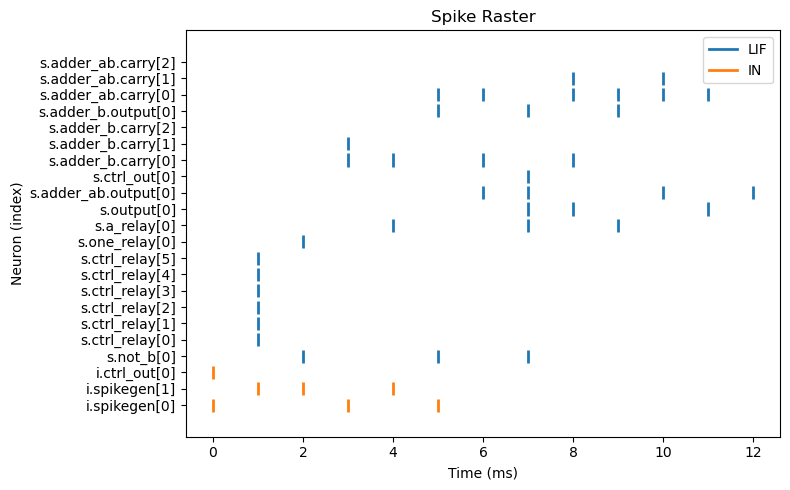

In [4]:
# Pass the built network to the Fugu backend
sim = SimFugu(net)

# Compile and run this network using Fugu's SNN simulator
sim.compile()
sim.run(20)

# We can also plot the spikes
sim.plot_spikes(figsize=(8,5), linewidths=2.0, tick_names=True)

In [5]:
# Print out the Fugu scaffold summary
sim.scaffold.summary(verbose=1)

Scaffold is built: True
-------------------------------------------------------
Bricks:

Brick No.: 0
Brick Tag: input
Brick Name: InputBrick
{'tag': 'input', 'name': 'InputBrick', 'brick': <sango.backend.fugu.fugu.SimFugu.DummyBrick object at 0x155e43770>, 'layer': 'input', 'ports': {'output': PortData(spec=PortSpec(name='output', description='', index=0, minimum=1, maximum=1, channels={}), channels={'data': ChannelData(spec=ChannelSpec(name='data', description='', coding='Raster', shape=(3,), required=True), neurons=['i.spikegen[0]', 'i.spikegen[1]', 'i.ctrl_out[0]'])})}, 'is_built': True}
Brick is built: True

Brick No.: 1
Brick Tag: sango
Brick Name: SangoBrick
{'tag': 'sango', 'name': 'SangoBrick', 'brick': <sango.backend.fugu.fugu.SimFugu.DummyBrick object at 0x155f56850>, 'layer': 'output', 'ports': {'input': PortData(spec=PortSpec(name='input', description='', index=0, minimum=1, maximum=1, channels={}), channels={'data': ChannelData(spec=ChannelSpec(name='data', description=''